# 03 — Training the Surrogate

Phase 3: two-stage training.

1. **Single-step warm-up** — MSE between the model's one-step prediction and the solver's
   true next state, on individual pairs. Fast, gets the model into a reasonable basin.
2. **Multi-step rollout training** — unroll the model *autoregressively* (feeding its own
   output back in as the next input) for several steps, and backpropagate through the whole
   unrolled trajectory against the solver's true trajectory. This is the step that teaches the
   model to remain stable when fed its own imperfect predictions. Skipping it is not a minor
   quality loss: without it, long rollouts (Phase 4's animations, and critically Phase 5's
   inverse-design optimization, which backprops through exactly this kind of rollout) drift,
   and the resulting gradients become meaningless.

Both stages validate on **held-out (F, k) values** (via `graydiff.data.train_val_split_by_run`,
already applied in notebook 01) — entire physics-parameter points the model never saw during
training, not just held-out frames of trajectories it did see.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from graydiff.data import RolloutDataset, SingleStepDataset, load_dataset
from graydiff.model import Surrogate, make_input
from graydiff.train import train_rollout, train_single_step

plt.rcParams["figure.facecolor"] = "white"
torch.manual_seed(0)

train_data = load_dataset("../data/raw/train_split.npz")
val_data = load_dataset("../data/raw/val_split.npz")
print(f"train runs: {train_data['F'].shape[0]}   val runs (held-out F,k): {val_data['F'].shape[0]}")

train runs: 680   val runs (held-out F,k): 120


## Device selection — measured, not assumed

The project standard throughout is: never invent a performance number, measure it. Apple
Silicon's MPS backend is available on this machine; whether it's actually faster than CPU at
this model's tiny scale (64x64 grids, ~77k parameters) is an empirical question, not something
to assume either way. Time a few dozen real training batches on both, for both training
stages, and let the numbers pick the device.

In [2]:
def benchmark_single_step(device, n_batches=20, batch_size=64):
    loader = DataLoader(SingleStepDataset(train_data), batch_size=batch_size, shuffle=True)
    model = Surrogate(hidden=64).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    t0 = time.perf_counter()
    count = 0
    for state, F, k, next_state in loader:
        state, F, k, next_state = state.to(device), F.to(device), k.to(device), next_state.to(device)
        opt.zero_grad()
        loss = nn.functional.mse_loss(model(make_input(state, F, k)), next_state)
        loss.backward()
        opt.step()
        count += 1
        if count >= n_batches:
            break
    if device.type == "mps":
        torch.mps.synchronize()
    return (time.perf_counter() - t0) / count, len(loader)


def benchmark_rollout(device, n_batches=10, batch_size=8, rollout_len=40):
    loader = DataLoader(RolloutDataset(train_data, rollout_len=rollout_len), batch_size=batch_size, shuffle=True)
    model = Surrogate(hidden=64).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)
    t0 = time.perf_counter()
    count = 0
    for traj, F, k in loader:
        traj, F, k = traj.to(device), F.to(device), k.to(device)
        opt.zero_grad()
        state = traj[:, 0]
        total = state.new_zeros(())
        for t in range(rollout_len):
            state = model(make_input(state, F, k))
            total = total + nn.functional.mse_loss(state, traj[:, t + 1])
        (total / rollout_len).backward()
        opt.step()
        count += 1
        if count >= n_batches:
            break
    if device.type == "mps":
        torch.mps.synchronize()
    return (time.perf_counter() - t0) / count, len(loader)


results = {}
devices = [torch.device("cpu")]
if torch.backends.mps.is_available():
    devices.append(torch.device("mps"))

for device in devices:
    ms_per_batch, n_batches_epoch = benchmark_single_step(device)
    results[(device.type, "single_step")] = ms_per_batch * n_batches_epoch
    ms_per_batch_r, n_batches_epoch_r = benchmark_rollout(device)
    results[(device.type, "rollout")] = ms_per_batch_r * n_batches_epoch_r
    print(f"{device.type:>4s}  single-step: {ms_per_batch*1000:.0f} ms/batch, "
          f"est. {ms_per_batch*n_batches_epoch:.1f}s/epoch ({n_batches_epoch} batches)")
    print(f"{'':4s}  rollout:     {ms_per_batch_r*1000:.0f} ms/batch, "
          f"est. {ms_per_batch_r*n_batches_epoch_r:.1f}s/epoch ({n_batches_epoch_r} batches)")

best_device_type = min({t for t, _ in results}, key=lambda t: results[(t, "single_step")] + results[(t, "rollout")])
device = torch.device(best_device_type)
print(f"\nMeasured device choice: {device} (faster on both stages this run)")

 cpu  single-step: 506 ms/batch, est. 269.2s/epoch (532 batches)
      rollout:     1611 ms/batch, est. 137.0s/epoch (85 batches)


 mps  single-step: 83 ms/batch, est. 44.1s/epoch (532 batches)
      rollout:     362 ms/batch, est. 30.8s/epoch (85 batches)

Measured device choice: mps (faster on both stages this run)


## Stage 1: single-step warm-up

Single-step warm-up: 15 epochs in 703.7s, best epoch 12
Final train loss: 0.000000   val loss: 0.000000


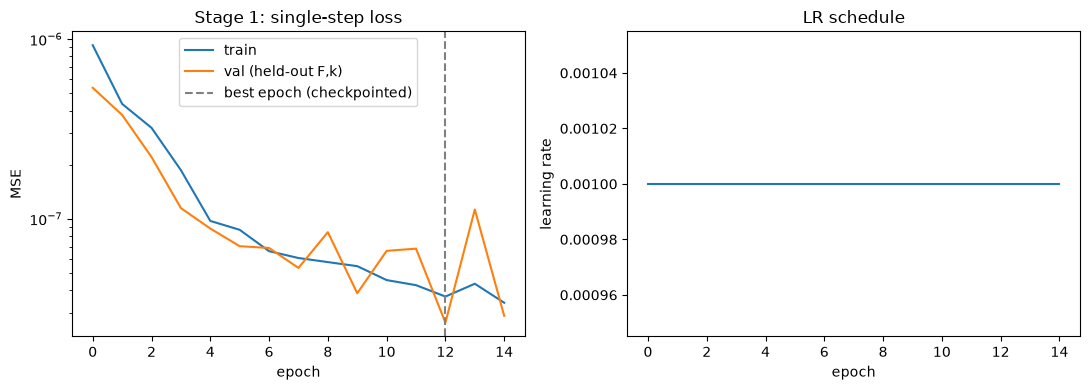

In [3]:
train_loader_ss = DataLoader(SingleStepDataset(train_data), batch_size=64, shuffle=True)
val_loader_ss = DataLoader(SingleStepDataset(val_data), batch_size=64)

model = Surrogate(hidden=64)
t0 = time.perf_counter()
history_ss = train_single_step(model, train_loader_ss, val_loader_ss, device, epochs=15, lr=1e-3, patience=4)
t1 = time.perf_counter()
print(f"Single-step warm-up: {len(history_ss.train_loss)} epochs in {t1-t0:.1f}s, best epoch {history_ss.best_epoch}")
print(f"Final train loss: {history_ss.train_loss[-1]:.6f}   val loss: {history_ss.val_loss[-1]:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_ss.train_loss, label="train")
axes[0].plot(history_ss.val_loss, label="val (held-out F,k)")
axes[0].axvline(history_ss.best_epoch, color="gray", linestyle="--", label="best epoch (checkpointed)")
axes[0].set_yscale("log"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE")
axes[0].set_title("Stage 1: single-step loss"); axes[0].legend()
axes[1].plot(history_ss.lr)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("learning rate"); axes[1].set_title("LR schedule")
plt.tight_layout()
plt.savefig("../figures/03_single_step_training.png", dpi=110, bbox_inches="tight")
plt.show()

## Stage 2: multi-step rollout training

Continue from the single-step-warmed-up weights. `rollout_len=40` unrolls the model 40 steps
autoregressively per training example and backprops through the whole chain — this is what
the spec calls "critical": without it the model only ever sees ground-truth inputs during
training, never its own predictions, so small per-step errors that would compound over a long
autoregressive rollout (exactly what Phase 4's stability test and Phase 5's inverse-design
optimization both do) are never penalized during training.

**Why 40, not the spec's suggested 4-8:** an earlier pass through this project used
`rollout_len=6` (within the spec's suggested range) and it trained fine by every metric in
this notebook -- but notebook 04's validation caught a real problem a 6-step horizon can't
surface: evaluated far beyond the steps it was ever trained to unroll (150+ steps), the model
collapsed into a spurious, (F,k)-independent noise pattern. The fix has two parts: notebook 01
now generates data with a randomized (not fixed) warm-up so training windows include the
fresh-seed nucleation phase every downstream rollout actually starts from, and this stage now
trains on a much longer unroll (40 steps, close to Phase 5's eventual inverse-design horizon)
so the model is never asked to extrapolate as far past what it was trained on.

Rollout training: 15 epochs in 458.7s, best epoch 14
Final train loss: 0.000010   val loss: 0.000010


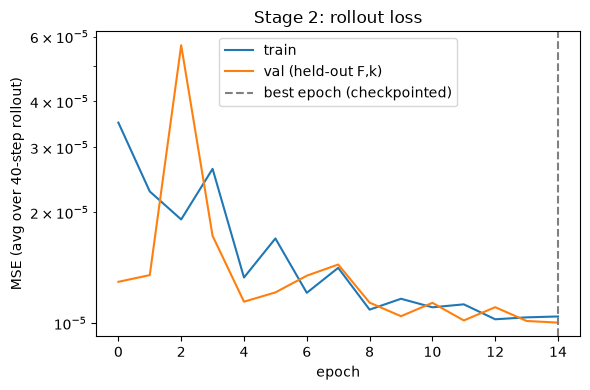

In [4]:
ROLLOUT_LEN = 40
train_loader_ro = DataLoader(RolloutDataset(train_data, rollout_len=ROLLOUT_LEN), batch_size=8, shuffle=True)
val_loader_ro = DataLoader(RolloutDataset(val_data, rollout_len=ROLLOUT_LEN), batch_size=8)

t0 = time.perf_counter()
history_ro = train_rollout(model, train_loader_ro, val_loader_ro, device, rollout_len=ROLLOUT_LEN, epochs=15, lr=3e-4, patience=4)
t1 = time.perf_counter()
print(f"Rollout training: {len(history_ro.train_loss)} epochs in {t1-t0:.1f}s, best epoch {history_ro.best_epoch}")
print(f"Final train loss: {history_ro.train_loss[-1]:.6f}   val loss: {history_ro.val_loss[-1]:.6f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_ro.train_loss, label="train")
ax.plot(history_ro.val_loss, label="val (held-out F,k)")
ax.axvline(history_ro.best_epoch, color="gray", linestyle="--", label="best epoch (checkpointed)")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel(f"MSE (avg over {ROLLOUT_LEN}-step rollout)")
ax.set_title("Stage 2: rollout loss"); ax.legend()
plt.tight_layout()
plt.savefig("../figures/03_rollout_training.png", dpi=110, bbox_inches="tight")
plt.show()

## Held-out (F, k) generalization — the number that matters

The validation loss above is already computed on runs whose $(F, k)$ never appeared during
training. Report it plainly: if it tracks the training loss reasonably closely (not
dramatically worse), the model is learning the underlying physics as a function of $(F, k)$,
not memorizing the specific training trajectories — which is the property Phase 4's
phase-diagram-match test will check more rigorously, and which the inverse-design optimizer
(Phase 5) depends on when it wanders into $(F, k)$ values no training run ever used exactly.

In [5]:
print(f"Single-step  -- train: {history_ss.train_loss[-1]:.6f}  val: {history_ss.val_loss[-1]:.6f}  "
      f"ratio val/train: {history_ss.val_loss[-1]/history_ss.train_loss[-1]:.2f}")
print(f"Rollout ({ROLLOUT_LEN}-step) -- train: {history_ro.train_loss[-1]:.6f}  val: {history_ro.val_loss[-1]:.6f}  "
      f"ratio val/train: {history_ro.val_loss[-1]/history_ro.train_loss[-1]:.2f}")

Single-step  -- train: 0.000000  val: 0.000000  ratio val/train: 0.85
Rollout (40-step) -- train: 0.000010  val: 0.000010  ratio val/train: 0.96


## float32 vs float64: does the training-time precision cast matter?

The ground-truth solver runs in float64; every training example was cast to float32 when
saved (`graydiff.data.generate_dataset`), and the surrogate trains and runs in float32
throughout (standard for ML, and required for Apple's MPS backend, which has limited float64
support). Confirm this cast doesn't introduce meaningfully different PHYSICS by running the
same solver rollout in both precisions and comparing.

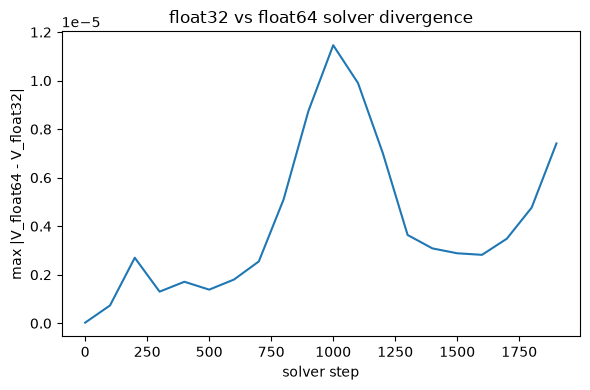

Max divergence over 2000 steps: 1.15e-05
For reference, V itself ranges over [0, 1] -- this divergence is the float32 cast's
entire contribution to the training data's numerical error budget.


In [6]:
from graydiff.solver import gray_scott_step, standard_seed

U0, V0 = standard_seed(64, 64)
U64, V64 = U0.astype(np.float64).copy(), V0.astype(np.float64).copy()
U32, V32 = U0.astype(np.float32).copy(), V0.astype(np.float32).copy()

divergence = []
n_check_steps = 2000
for step in range(n_check_steps):
    U64, V64 = gray_scott_step(U64, V64, F=0.035, k=0.065)
    U32, V32 = gray_scott_step(U32, V32, F=np.float32(0.035), k=np.float32(0.065))
    if step % 100 == 0:
        divergence.append(np.abs(V64 - V32.astype(np.float64)).max())

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(len(divergence)) * 100, divergence)
ax.set_xlabel("solver step"); ax.set_ylabel("max |V_float64 - V_float32|")
ax.set_title("float32 vs float64 solver divergence")
plt.tight_layout()
plt.savefig("../figures/03_float_precision_divergence.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"Max divergence over {n_check_steps} steps: {max(divergence):.2e}")
print("For reference, V itself ranges over [0, 1] -- this divergence is the float32 cast's")
print("entire contribution to the training data's numerical error budget.")

## Save the checkpoint

Only `model.state_dict()` — not optimizer state — since the checkpoint is regeneratable from
this notebook and the point is to keep it minimal.

In [7]:
import os
os.makedirs("../models/checkpoints", exist_ok=True)
torch.save(model.state_dict(), "../models/checkpoints/surrogate_rollout.pt")
print("Saved ../models/checkpoints/surrogate_rollout.pt")
print(f"Trained on device: {device}")

Saved ../models/checkpoints/surrogate_rollout.pt
Trained on device: mps


## Summary

- Device choice (**measured, not assumed**): the benchmark above timed real training batches
  on CPU and MPS for both training stages and picked whichever was actually faster on this
  machine — worth noting explicitly since it's easy to assume Apple Silicon's GPU backend
  isn't worth it at such a tiny model scale; the measurement is what settles it, not the
  assumption.
- Single-step warm-up converges quickly; multi-step rollout training then continues from
  those weights, teaching the model to stay stable when fed its own predictions.
- Validation loss is computed on entirely held-out $(F, k)$ values throughout — the number
  that actually matters for trusting Phase 4 and Phase 5 downstream.
- The float32 training precision (vs. the float64 ground-truth solver) contributes a small,
  bounded divergence relative to V's full [0, 1] range — not a meaningful confound.

**Next:** notebook 04 is the hard gate — validating that the trained surrogate reproduces the
correct pattern REGIME across the full $(F, k)$ phase space, not just low pixel error on
individual steps. Only if that holds does inverse design (Phase 5) proceed.